In [1]:
import math
import torch
import time
import random
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.parameter import Parameter
from torch.nn import init
from torch import Tensor
from scipy.special import gamma 
import matplotlib.pyplot as plt
# nn.utils.clip_grad_norm_(model.parameters(), max_norm=50.0, norm_type=2)

In [281]:
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb}'
custom_params = {
    'font.size': 20,
    'lines.linewidth': 1,
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
}

In [3]:
def get_memory_usage():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated()/ (1024*1024)
    return 0

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [6]:
class Fractional_Order_Matrix_Differential_Solver(torch.autograd.Function):
    @staticmethod
    def forward(ctx,input1,w,b,alpha):
        alpha = torch.tensor(alpha)
        ctx.save_for_backward(input1,w,b,alpha)
        outputs = input1@w + b
        return outputs

    @staticmethod
    def backward(ctx, grad_outputs):
        input1,w,b,alpha = ctx.saved_tensors
        x_fractional, w_fractional = Fractional_Order_Matrix_Differential_Solver.Fractional_Order_Matrix_Differential_Linear(input1,w,b,alpha)   
        x_grad = torch.mm(grad_outputs,x_fractional)
        w_grad = torch.mm(w_fractional,grad_outputs)
        b_grad = grad_outputs.sum(dim=0)
        return x_grad, w_grad, b_grad,None

    @staticmethod
    def Fractional_Order_Matrix_Differential_Linear(xs,ws,b,alpha):
            if xs.dim() == 2:
                #w
                wf = ws[:,0].view(1,-1)
                #main
                w_main = torch.mul(xs,(torch.abs(wf)+1e-8)**(1-alpha)/gamma(2-alpha))
                #partial
                x_rows, x_cols = xs.size()
                bias = torch.full((x_rows, x_cols),b[0].item())
                bias = bias.to(device)
                w_partial = torch.mul(torch.mm(xs,wf.T).view(-1,1).expand(-1,x_cols) - torch.mul(xs,wf) + bias, torch.sgn(wf)*(torch.abs(wf)+1e-8)**(-alpha)/gamma(1-alpha))
                return ws.T, (w_main + w_partial).T
            else:
                mat_list_x = []
                for jj in range(xs.shape[0]):
                    #w
                    xs_jj = xs[jj]
                    wf = ws[:,0].view(1,-1)
                    #main
                    w_main = torch.mul(xs_jj,(torch.abs(wf)+1e-8)**(1-alpha)/gamma(2-alpha))
                    #partial
                    x_rows, x_cols = xs_jj.size()
                    bias = torch.full((x_rows, x_cols),b[0].item())
                    bias = bias.to(device)
                    w_partial = torch.mul(torch.mm(xs_jj,wf.T).view(-1,1).expand(-1,x_cols) - torch.mul(xs_jj,wf) + bias, torch.sgn(wf)*(torch.abs(wf)+1e-8)**(-alpha)/gamma(1-alpha))

                    mat_list_x.append((w_main + w_partial).T)
                
                return ws.T, torch.stack(mat_list_x)

class FLinear(nn.Module):
    
    __constants__ = ['in_features', 'out_features']
    in_features: int
    out_features: int
    weight: Tensor

    def __init__(self, in_features: int, out_features: int, alpha=0.9, bias: bool = True,
                 device=None, dtype=None) -> None:
        factory_kwargs = {'device': device, 'dtype': dtype}
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.alpha = alpha
        self.weight = Parameter(torch.empty((in_features, out_features), **factory_kwargs))
        if bias:
            self.bias = Parameter(torch.empty(out_features, **factory_kwargs))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        return Fractional_Order_Matrix_Differential_Solver.apply(x, self.weight, self.bias, self.alpha)

    def extra_repr(self) -> str:
        return f"in_features={self.in_features}, out_features={self.out_features}, bias={self.bias is not None}"

In [7]:
def split(X,y):
    X_train,X_temp,y_train,y_temp = train_test_split(X,y,test_size=0.3,shuffle=False)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.333,shuffle=False)
    return X_train,X_val,X_test,y_train,y_val,y_test

def MSE(pred,true):
    return np.mean((pred-true)**2)

def MAE(pred, true):
    return np.mean(np.abs(pred-true))

def RMSE(pred,true):
    return np.sqrt(np.mean((pred-true)**2))

def MAPE(pred, true):
    return np.mean(np.abs((pred - true) / true))

In [289]:
slide_windows_size = 192  #i.e.,input length 192
pred_length = 384     #i.e.,prediction lengths 384
stock = 'DJI'    #ETTh1,DJI
df_DJIA = pd.read_csv(r'./data/'+stock+'.csv')
# del df_DJIA['date']        #ETTh1
del df_DJIA['Date']        #DJI
scaler = MinMaxScaler(feature_range=(0, 1))
# scaler = StandardScaler()

sca_DJIA = scaler.fit_transform(df_DJIA)

features_j = 4    #ETTh1:6,DJI:4
def create_sequences(data, slide_windows_size, pred_length):
    X, y = [], []
    for i in range(len(data) - slide_windows_size - pred_length + 1):
        X.append(data[i:i+slide_windows_size, :])  # sliding window size [seq_len, features]
        y.append(data[i+slide_windows_size:i+slide_windows_size+pred_length, features_j])  
    return np.array(X), np.array(y)

X, y = create_sequences(sca_DJIA, slide_windows_size, pred_length)
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

X_train,X_val,X_test,y_train,y_val,y_test = split(X,y)   #7:2:1 

In [306]:
alpha = 1.0

batch_size = 256   #256
set_seed()
num_feature = 5    #ETTh2:7,DJI:5 
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128,output_size=pred_length):   
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = FLinear(input_size, hidden_size1, alpha)                              
        self.linear2 = FLinear(hidden_size1, hidden_size2, alpha) 
        self.linear3 = FLinear(hidden_size2, output_size, alpha)    
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(0.2)
     

    def forward(self, x):
        x = self.flatten(x)    # (batch_size, seq_len*num_features)
        x = self.dropout(self.leakrelu(self.linear1(x))) 
        x = self.dropout(self.leakrelu(self.linear2(x)))
        x = self.linear3(x)
        return x

set_seed()
model = MLP(input_size=slide_windows_size*num_feature).to(device)

train_loss10 = []    ###
val_loss10 = []      ###

lr =1e-4    #ETTh1:1e-4,DJI:1e-3
weight_decay = 1e-4
max_norm = 50

num_epochs = 100  
best_loss = 10
criterion = nn.MSELoss()
# optimizer = torch.optim.SGD(model.parameters(),lr=lr,momentum=momentum)
optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight_decay)
for ii in range(num_epochs):
    model.train()
    loss_sum = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_sum += loss
        loss.backward()   
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm, norm_type=2)
        optimizer.step()
    train_loss10.append(loss_sum.cpu().detach().numpy())     ###########
    
    print(f"Epoch {ii + 1}/{num_epochs}, Train Loss: {loss_sum.cpu().detach().numpy():.4f}")
        
    model.eval()
    with torch.no_grad():
        Val_outputs = model(X_val)
        MSE_val = MSE(y_val.cpu().detach().numpy(),Val_outputs.cpu().detach().numpy())
        
        val_loss10.append(MSE_val)   ########################Validation_loss
        
        print(f"Epoch {ii + 1}/{num_epochs}, Val Loss: {MSE_val:.4f}")  
        print('')
        if best_loss > MSE_val:
            best_loss = MSE_val
            torch.save(model.state_dict(), r'./model/'+stock+'_model_fractional_'+str(alpha).replace(".", "_")+'_'+str(pred_length)+'.pth')
        

Epoch 1/100, Train Loss: 0.6344
Epoch 1/100, Val Loss: 0.2896

Epoch 2/100, Train Loss: 0.4662
Epoch 2/100, Val Loss: 0.1686

Epoch 3/100, Train Loss: 0.2978
Epoch 3/100, Val Loss: 0.0786

Epoch 4/100, Train Loss: 0.1860
Epoch 4/100, Val Loss: 0.0376

Epoch 5/100, Train Loss: 0.1344
Epoch 5/100, Val Loss: 0.0241

Epoch 6/100, Train Loss: 0.1103
Epoch 6/100, Val Loss: 0.0163

Epoch 7/100, Train Loss: 0.0957
Epoch 7/100, Val Loss: 0.0151

Epoch 8/100, Train Loss: 0.0852
Epoch 8/100, Val Loss: 0.0151

Epoch 9/100, Train Loss: 0.0777
Epoch 9/100, Val Loss: 0.0123

Epoch 10/100, Train Loss: 0.0705
Epoch 10/100, Val Loss: 0.0111

Epoch 11/100, Train Loss: 0.0655
Epoch 11/100, Val Loss: 0.0123

Epoch 12/100, Train Loss: 0.0618
Epoch 12/100, Val Loss: 0.0122

Epoch 13/100, Train Loss: 0.0592
Epoch 13/100, Val Loss: 0.0143

Epoch 14/100, Train Loss: 0.0568
Epoch 14/100, Val Loss: 0.0096

Epoch 15/100, Train Loss: 0.0539
Epoch 15/100, Val Loss: 0.0117

Epoch 16/100, Train Loss: 0.0523
Epoch 16/1

In [307]:
alpha = 0.9

batch_size = 256   #256
set_seed()
# num_feature = 7    #ETTh2:7,DJI:5 
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128,output_size=pred_length):   
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = FLinear(input_size, hidden_size1, alpha)                              
        self.linear2 = FLinear(hidden_size1, hidden_size2, alpha) 
        self.linear3 = FLinear(hidden_size2, output_size, alpha)    
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(0.2)
     

    def forward(self, x):
        x = self.flatten(x)    # (batch_size, seq_len*num_features)
        x = self.dropout(self.leakrelu(self.linear1(x))) 
        x = self.dropout(self.leakrelu(self.linear2(x)))
        x = self.linear3(x)
        return x

set_seed()
model = MLP(input_size=slide_windows_size*num_feature).to(device)

train_loss09 = []    ###
val_loss09 = []      ###

# lr =1e-2     #ETTh1:1e-3,DJI:1e-2
# momentum = 0.9
  
best_loss = 10
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight_decay)
for ii in range(num_epochs):
    model.train()
    loss_sum = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_sum += loss
        loss.backward()   
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm, norm_type=2)
        optimizer.step()
    train_loss09.append(loss_sum.cpu().detach().numpy())     ###########
    
    print(f"Epoch {ii + 1}/{num_epochs}, Train Loss: {loss_sum.cpu().detach().numpy():.4f}")
        
    model.eval()
    with torch.no_grad():
        Val_outputs = model(X_val)
        MSE_val = MSE(y_val.cpu().detach().numpy(),Val_outputs.cpu().detach().numpy())
        
        val_loss09.append(MSE_val)   ########################Validation_loss
        
        print(f"Epoch {ii + 1}/{num_epochs}, Val Loss: {MSE_val:.4f}")  
        print('')
        if best_loss > MSE_val:
            best_loss = MSE_val
            torch.save(model.state_dict(), r'./model/'+stock+'_model_fractional_'+str(alpha).replace(".", "_")+'_'+str(pred_length)+'.pth')
        

Epoch 1/100, Train Loss: 0.6663
Epoch 1/100, Val Loss: 0.3301

Epoch 2/100, Train Loss: 0.5904
Epoch 2/100, Val Loss: 0.2872

Epoch 3/100, Train Loss: 0.4920
Epoch 3/100, Val Loss: 0.2309

Epoch 4/100, Train Loss: 0.3757
Epoch 4/100, Val Loss: 0.1626

Epoch 5/100, Train Loss: 0.2562
Epoch 5/100, Val Loss: 0.0942

Epoch 6/100, Train Loss: 0.1708
Epoch 6/100, Val Loss: 0.0513

Epoch 7/100, Train Loss: 0.1269
Epoch 7/100, Val Loss: 0.0307

Epoch 8/100, Train Loss: 0.1043
Epoch 8/100, Val Loss: 0.0228

Epoch 9/100, Train Loss: 0.0928
Epoch 9/100, Val Loss: 0.0181

Epoch 10/100, Train Loss: 0.0855
Epoch 10/100, Val Loss: 0.0144

Epoch 11/100, Train Loss: 0.0798
Epoch 11/100, Val Loss: 0.0129

Epoch 12/100, Train Loss: 0.0779
Epoch 12/100, Val Loss: 0.0124

Epoch 13/100, Train Loss: 0.0752
Epoch 13/100, Val Loss: 0.0118

Epoch 14/100, Train Loss: 0.0735
Epoch 14/100, Val Loss: 0.0118

Epoch 15/100, Train Loss: 0.0699
Epoch 15/100, Val Loss: 0.0118

Epoch 16/100, Train Loss: 0.0679
Epoch 16/1

In [308]:
alpha = 0.8

batch_size = 256   #256
set_seed()
# num_feature = 5    #ETTh2:7,DJI:5 
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128,output_size=pred_length):   
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = FLinear(input_size, hidden_size1, alpha)                              
        self.linear2 = FLinear(hidden_size1, hidden_size2, alpha) 
        self.linear3 = FLinear(hidden_size2, output_size, alpha)    
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(0.2)
     

    def forward(self, x):
        x = self.flatten(x)    # (batch_size, seq_len*num_features)
        x = self.dropout(self.leakrelu(self.linear1(x))) 
        x = self.dropout(self.leakrelu(self.linear2(x)))
        x = self.linear3(x)
        return x

set_seed()
model = MLP(input_size=slide_windows_size*num_feature).to(device)

train_loss08 = []    ###
val_loss08 = []      ###

# lr =1e-2     #ETTh1:1e-3,DJI:1e-2
# momentum = 0.9

best_loss = 10
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight_decay)
for ii in range(num_epochs):
    model.train()
    loss_sum = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_sum += loss
        loss.backward()   
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm, norm_type=2)
        optimizer.step()
    train_loss08.append(loss_sum.cpu().detach().numpy())     ###########
    
    print(f"Epoch {ii + 1}/{num_epochs}, Train Loss: {loss_sum.cpu().detach().numpy():.4f}")
        
    model.eval()
    with torch.no_grad():
        Val_outputs = model(X_val)
        MSE_val = MSE(y_val.cpu().detach().numpy(),Val_outputs.cpu().detach().numpy())
        
        val_loss08.append(MSE_val)   ########################Validation_loss
        
        print(f"Epoch {ii + 1}/{num_epochs}, Val Loss: {MSE_val:.4f}")  
        print('')
        if best_loss > MSE_val:
            best_loss = MSE_val
            torch.save(model.state_dict(), r'./model/'+stock+'_model_fractional_'+str(alpha).replace(".", "_")+'_'+str(pred_length)+'.pth')
        

Epoch 1/100, Train Loss: 0.6783
Epoch 1/100, Val Loss: 0.3412

Epoch 2/100, Train Loss: 0.6215
Epoch 2/100, Val Loss: 0.3091

Epoch 3/100, Train Loss: 0.5345
Epoch 3/100, Val Loss: 0.2545

Epoch 4/100, Train Loss: 0.4079
Epoch 4/100, Val Loss: 0.1740

Epoch 5/100, Train Loss: 0.2602
Epoch 5/100, Val Loss: 0.0849

Epoch 6/100, Train Loss: 0.1632
Epoch 6/100, Val Loss: 0.0436

Epoch 7/100, Train Loss: 0.1224
Epoch 7/100, Val Loss: 0.0309

Epoch 8/100, Train Loss: 0.1022
Epoch 8/100, Val Loss: 0.0217

Epoch 9/100, Train Loss: 0.0918
Epoch 9/100, Val Loss: 0.0158

Epoch 10/100, Train Loss: 0.0855
Epoch 10/100, Val Loss: 0.0121

Epoch 11/100, Train Loss: 0.0824
Epoch 11/100, Val Loss: 0.0105

Epoch 12/100, Train Loss: 0.0827
Epoch 12/100, Val Loss: 0.0099

Epoch 13/100, Train Loss: 0.0816
Epoch 13/100, Val Loss: 0.0096

Epoch 14/100, Train Loss: 0.0812
Epoch 14/100, Val Loss: 0.0096

Epoch 15/100, Train Loss: 0.0800
Epoch 15/100, Val Loss: 0.0095

Epoch 16/100, Train Loss: 0.0810
Epoch 16/1

In [309]:
alpha = 0.7

batch_size = 256   #256
set_seed()
# num_feature = 5    #ETTh1:7,DJI:5 
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128,output_size=pred_length):   
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = FLinear(input_size, hidden_size1, alpha)                              
        self.linear2 = FLinear(hidden_size1, hidden_size2, alpha) 
        self.linear3 = FLinear(hidden_size2, output_size, alpha)    
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(0.2)
     

    def forward(self, x):
        x = self.flatten(x)    # (batch_size, seq_len*num_features)
        x = self.dropout(self.leakrelu(self.linear1(x))) 
        x = self.dropout(self.leakrelu(self.linear2(x)))
        x = self.linear3(x)
        return x

set_seed()
model = MLP(input_size=slide_windows_size*num_feature).to(device)

train_loss07 = []    ###
val_loss07 = []      ###

# lr =1e-2     #ETTh1:1e-3,DJI:1e-2
# momentum = 0.9
 
best_loss = 10
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight_decay)
for ii in range(num_epochs):
    model.train()
    loss_sum = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_sum += loss
        loss.backward()   
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm, norm_type=2)
        optimizer.step()
    train_loss07.append(loss_sum.cpu().detach().numpy())     ###########
    
    print(f"Epoch {ii + 1}/{num_epochs}, Train Loss: {loss_sum.cpu().detach().numpy():.4f}")
        
    model.eval()
    with torch.no_grad():
        Val_outputs = model(X_val)
        MSE_val = MSE(y_val.cpu().detach().numpy(),Val_outputs.cpu().detach().numpy())
        
        val_loss07.append(MSE_val)   ########################Validation_loss
        
        print(f"Epoch {ii + 1}/{num_epochs}, Val Loss: {MSE_val:.4f}")  
        print('')
        if best_loss > MSE_val:
            best_loss = MSE_val
            torch.save(model.state_dict(), r'./model/'+stock+'_model_fractional_'+str(alpha).replace(".", "_")+'_'+str(pred_length)+'.pth')
    

Epoch 1/100, Train Loss: 0.6838
Epoch 1/100, Val Loss: 0.3469

Epoch 2/100, Train Loss: 0.6389
Epoch 2/100, Val Loss: 0.3238

Epoch 3/100, Train Loss: 0.5750
Epoch 3/100, Val Loss: 0.2822

Epoch 4/100, Train Loss: 0.4683
Epoch 4/100, Val Loss: 0.2096

Epoch 5/100, Train Loss: 0.3111
Epoch 5/100, Val Loss: 0.1085

Epoch 6/100, Train Loss: 0.1844
Epoch 6/100, Val Loss: 0.0464

Epoch 7/100, Train Loss: 0.1310
Epoch 7/100, Val Loss: 0.0304

Epoch 8/100, Train Loss: 0.1069
Epoch 8/100, Val Loss: 0.0221

Epoch 9/100, Train Loss: 0.0971
Epoch 9/100, Val Loss: 0.0163

Epoch 10/100, Train Loss: 0.0908
Epoch 10/100, Val Loss: 0.0137

Epoch 11/100, Train Loss: 0.0856
Epoch 11/100, Val Loss: 0.0122

Epoch 12/100, Train Loss: 0.0833
Epoch 12/100, Val Loss: 0.0121

Epoch 13/100, Train Loss: 0.0822
Epoch 13/100, Val Loss: 0.0113

Epoch 14/100, Train Loss: 0.0802
Epoch 14/100, Val Loss: 0.0127

Epoch 15/100, Train Loss: 0.0781
Epoch 15/100, Val Loss: 0.0126

Epoch 16/100, Train Loss: 0.0774
Epoch 16/1

In [310]:
alpha = 0.6

batch_size = 256   #256
set_seed()
# num_feature = 5    #ETTh1:7,DJI:5 
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=256, hidden_size2=128,output_size=pred_length):   
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = FLinear(input_size, hidden_size1, alpha)                              
        self.linear2 = FLinear(hidden_size1, hidden_size2, alpha) 
        self.linear3 = FLinear(hidden_size2, output_size, alpha)    
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(0.2)
     

    def forward(self, x):
        x = self.flatten(x)    # (batch_size, seq_len*num_features)
        x = self.dropout(self.leakrelu(self.linear1(x))) 
        x = self.dropout(self.leakrelu(self.linear2(x)))
        x = self.linear3(x)
        return x

set_seed()
model = MLP(input_size=slide_windows_size*num_feature).to(device)

train_loss06 = []    ###
val_loss06 = []      ###

# lr =1e-2     #ETTh1:1e-3,DJI:1e-2
# momentum = 0.9
  
best_loss = 10
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=weight_decay)
for ii in range(num_epochs):
    model.train()
    loss_sum = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_sum += loss
        loss.backward()  
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm, norm_type=2)
        optimizer.step()
    train_loss06.append(loss_sum.cpu().detach().numpy())     ###########
    
    print(f"Epoch {ii + 1}/{num_epochs}, Train Loss: {loss_sum.cpu().detach().numpy():.4f}")
        
    model.eval()
    with torch.no_grad():
        Val_outputs = model(X_val)
        MSE_val = MSE(y_val.cpu().detach().numpy(),Val_outputs.cpu().detach().numpy())
        
        val_loss06.append(MSE_val)   ########################Validation_loss
        
        print(f"Epoch {ii + 1}/{num_epochs}, Val Loss: {MSE_val:.4f}")  
        print('')
        if best_loss > MSE_val:
            best_loss = MSE_val
            torch.save(model.state_dict(), r'./model/'+stock+'_model_fractional_'+str(alpha).replace(".", "_")+'_'+str(pred_length)+'.pth')
    

Epoch 1/100, Train Loss: 0.6879
Epoch 1/100, Val Loss: 0.3506

Epoch 2/100, Train Loss: 0.6502
Epoch 2/100, Val Loss: 0.3328

Epoch 3/100, Train Loss: 0.6020
Epoch 3/100, Val Loss: 0.3038

Epoch 4/100, Train Loss: 0.5279
Epoch 4/100, Val Loss: 0.2566

Epoch 5/100, Train Loss: 0.4106
Epoch 5/100, Val Loss: 0.1881

Epoch 6/100, Train Loss: 0.2837
Epoch 6/100, Val Loss: 0.1193

Epoch 7/100, Train Loss: 0.1891
Epoch 7/100, Val Loss: 0.0692

Epoch 8/100, Train Loss: 0.1351
Epoch 8/100, Val Loss: 0.0412

Epoch 9/100, Train Loss: 0.1099
Epoch 9/100, Val Loss: 0.0263

Epoch 10/100, Train Loss: 0.0953
Epoch 10/100, Val Loss: 0.0171

Epoch 11/100, Train Loss: 0.0877
Epoch 11/100, Val Loss: 0.0134

Epoch 12/100, Train Loss: 0.0832
Epoch 12/100, Val Loss: 0.0145

Epoch 13/100, Train Loss: 0.0814
Epoch 13/100, Val Loss: 0.0138

Epoch 14/100, Train Loss: 0.0783
Epoch 14/100, Val Loss: 0.0141

Epoch 15/100, Train Loss: 0.0758
Epoch 15/100, Val Loss: 0.0139

Epoch 16/100, Train Loss: 0.0755
Epoch 16/1

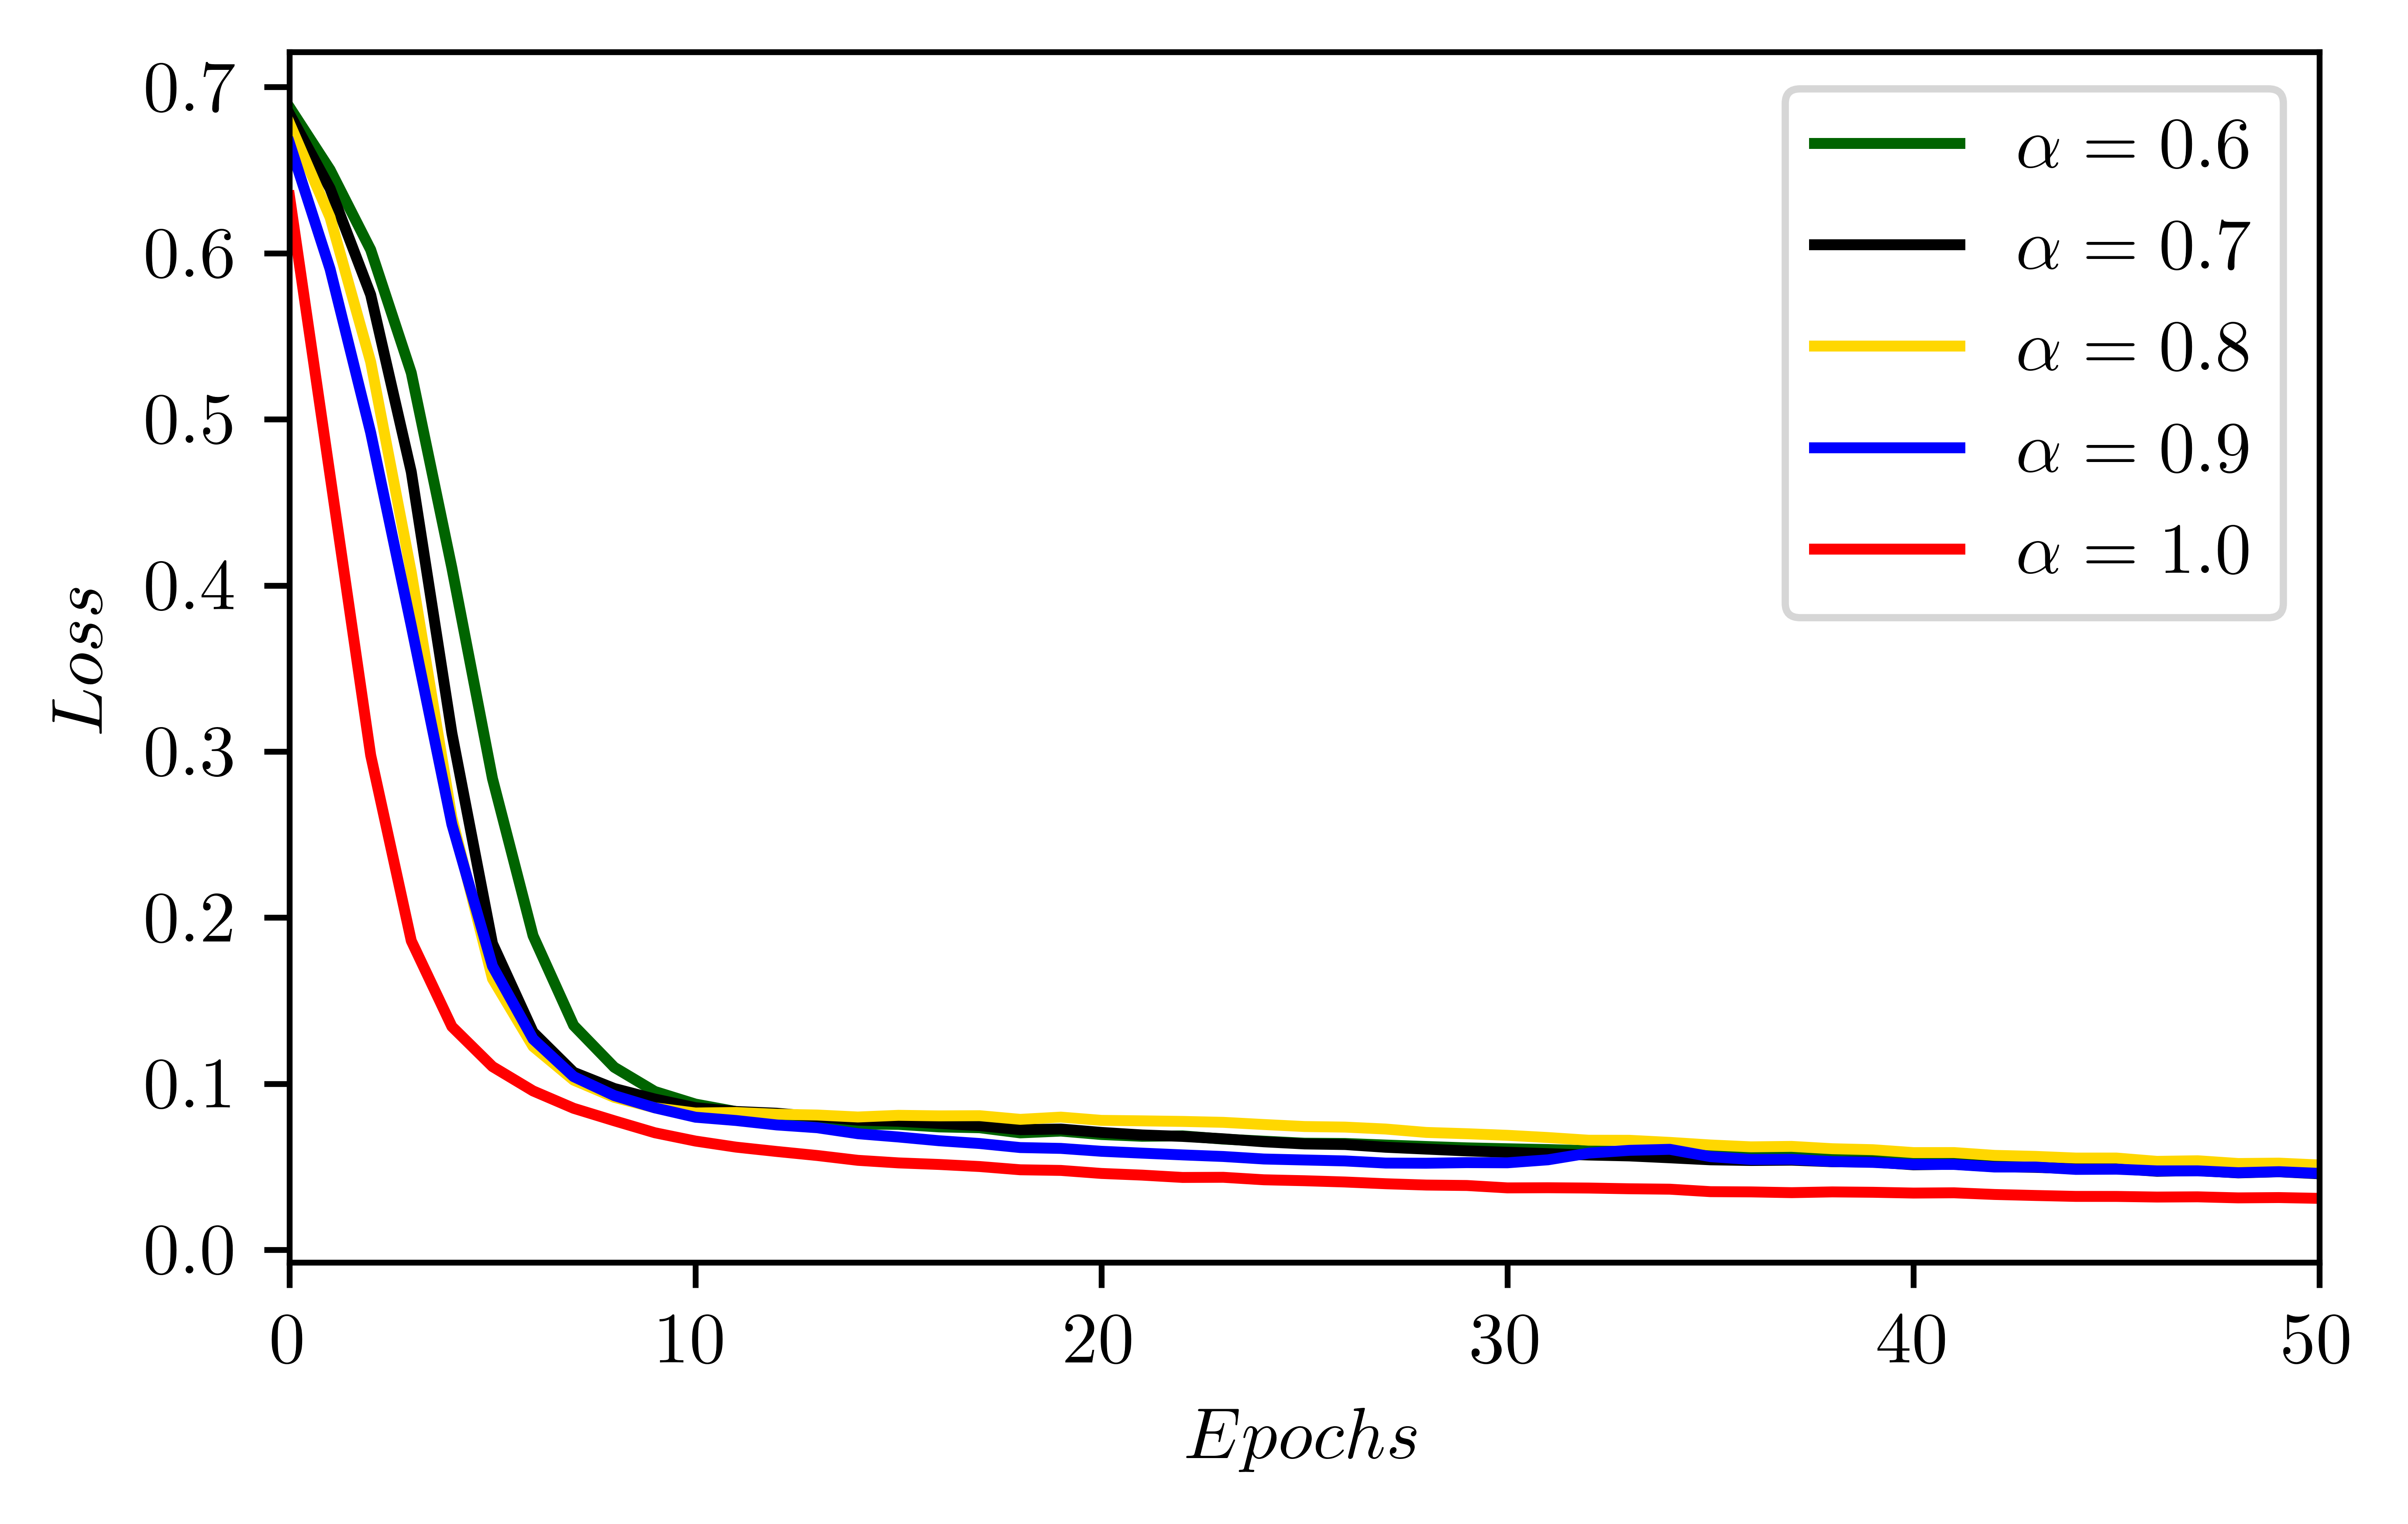

In [320]:
plt.figure(figsize=(5,3),dpi=1200)   #1200
plt.plot(train_loss06,c='darkgreen',label=r'$\alpha=0.6$')
plt.plot(train_loss07,c='k',label=r'$\alpha=0.7$')
plt.plot(train_loss08,c='gold',label=r'$\alpha=0.8$')
plt.plot(train_loss09,c='b',label=r'$\alpha=0.9$')
plt.plot(train_loss10,c='r',label=r'$\alpha=1.0$')
plt.xlim(0,50)
# plt.ylim(0,9)
plt.xlabel('$Epochs$')
plt.ylabel('$Loss$')
plt.legend()
# plt.savefig('picture/fig5_a.svg',bbox_inches='tight',format='svg')
# plt.savefig('picture/fig5_a.pdf',bbox_inches='tight',format='pdf')
plt.show()

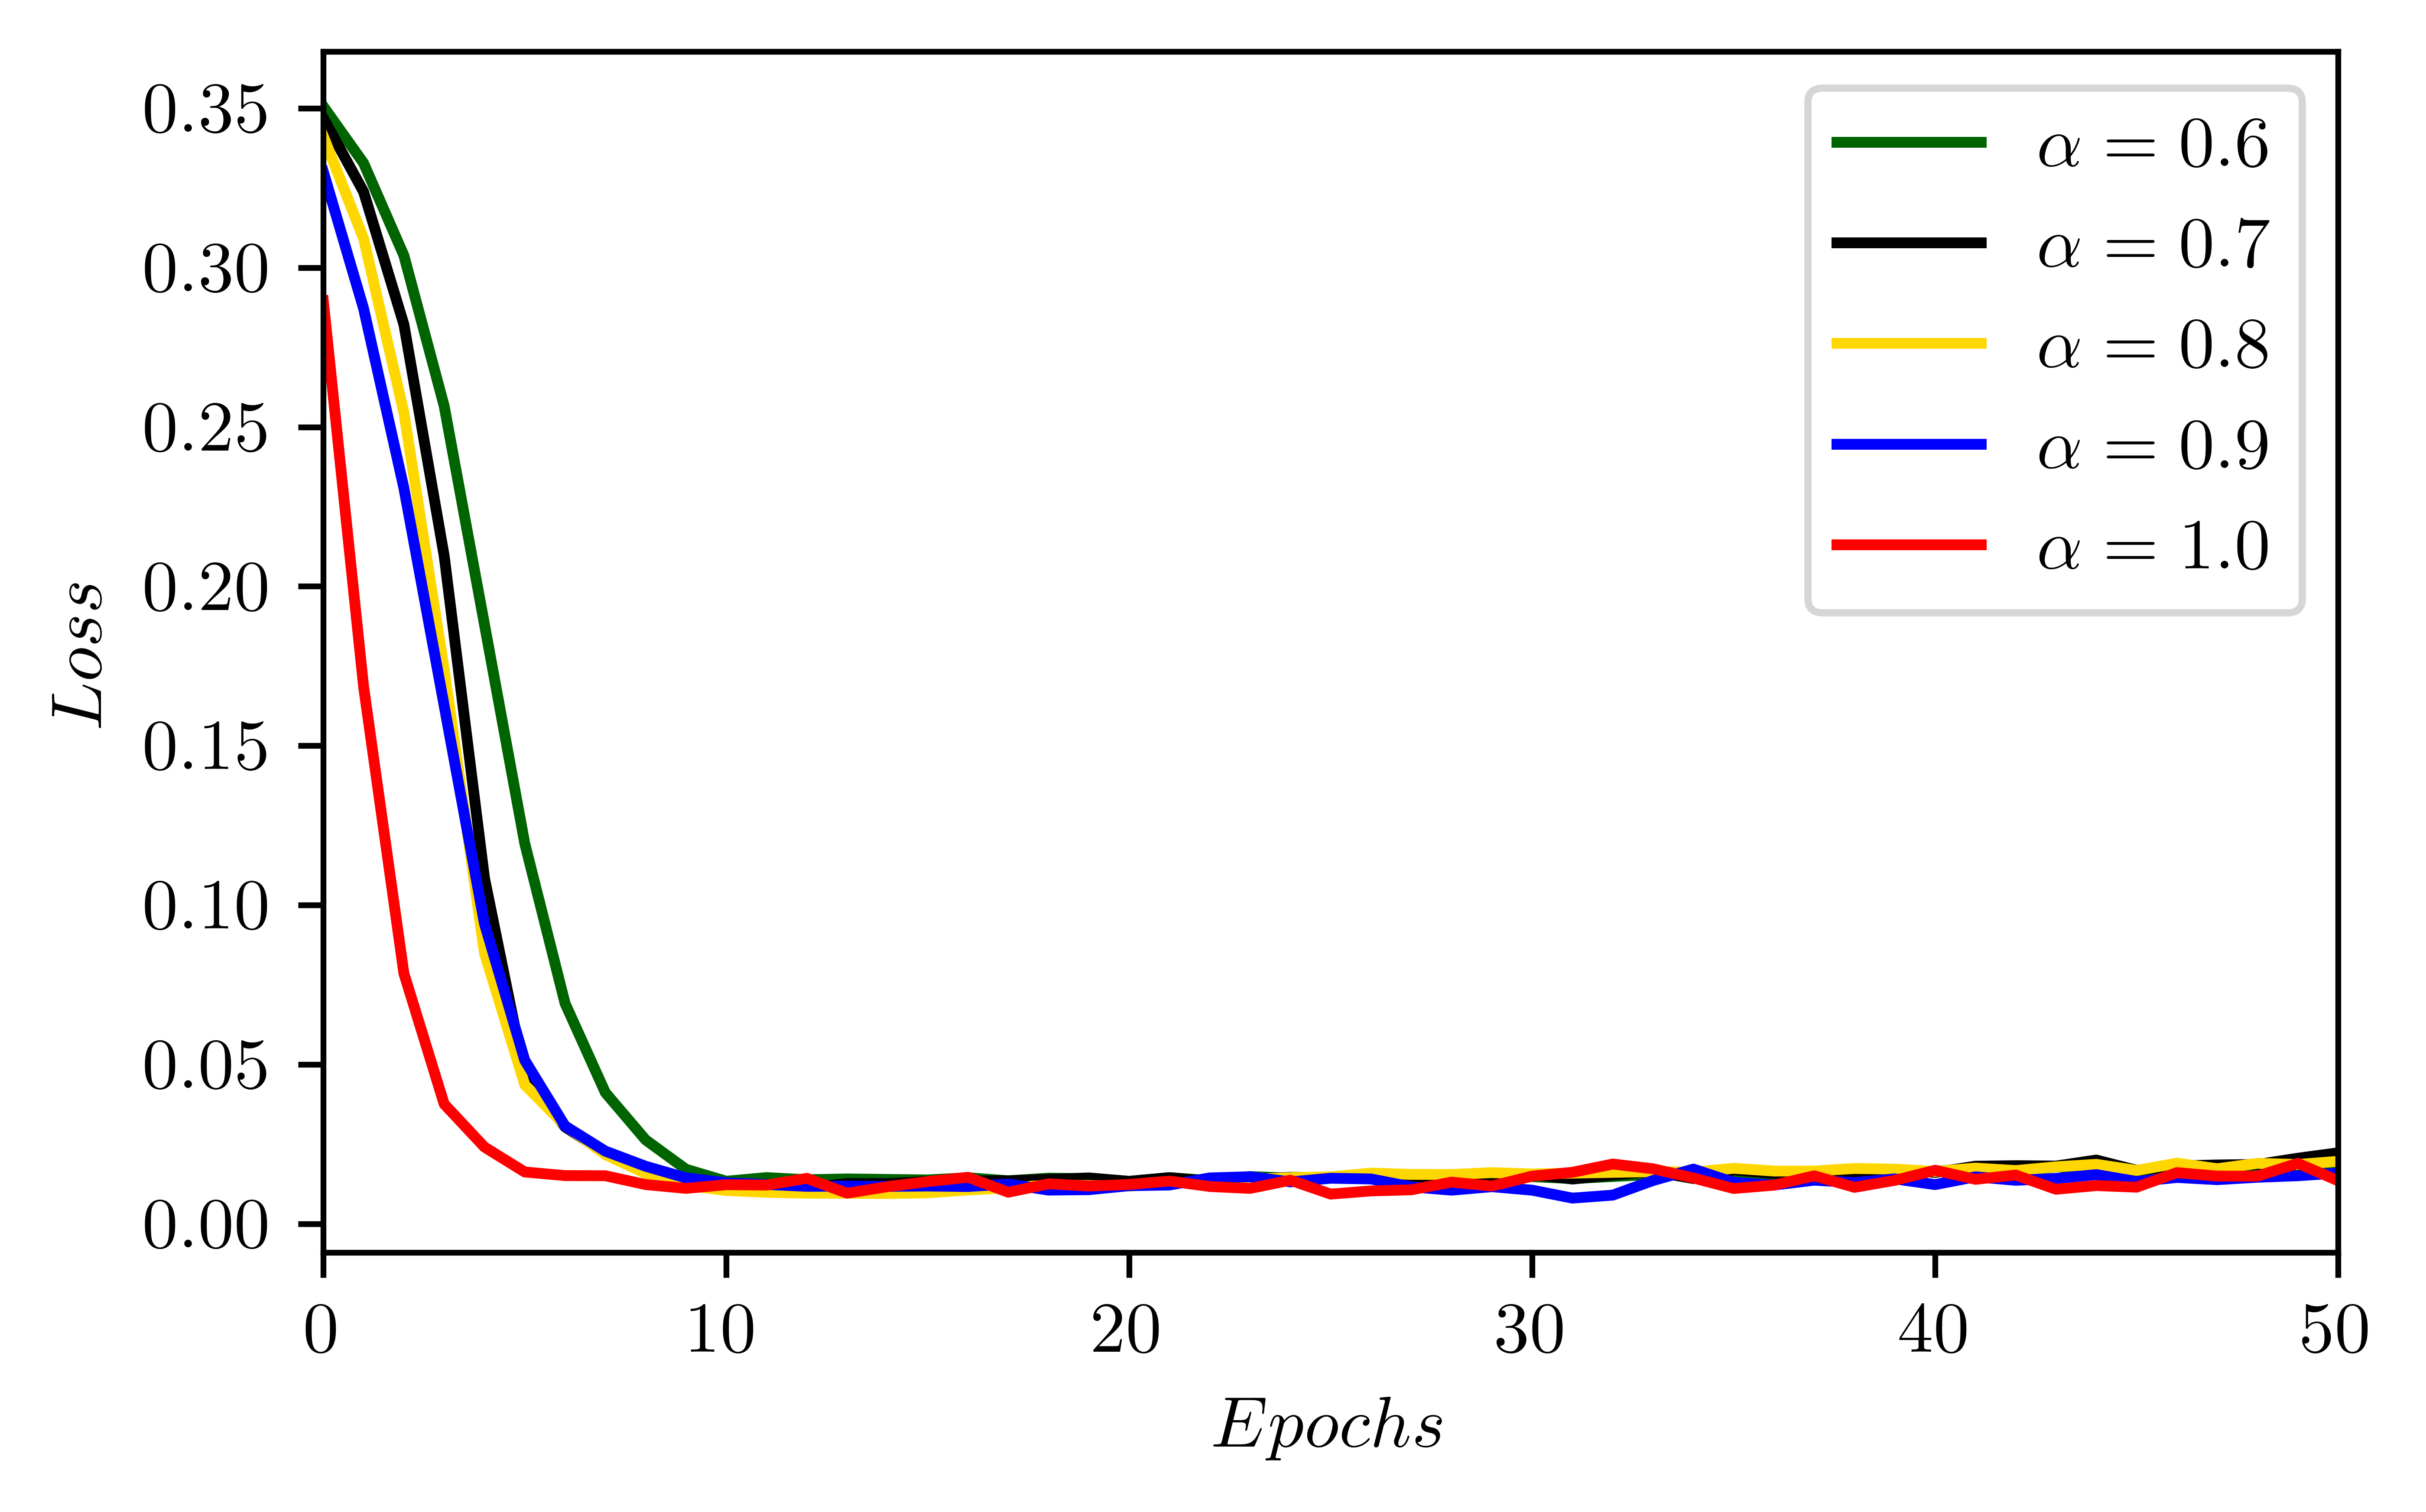

In [321]:
plt.figure(figsize=(5,3),dpi=1200)   #1200
plt.plot(val_loss06,c='darkgreen',label=r'$\alpha=0.6$')
plt.plot(val_loss07,c='k',label=r'$\alpha=0.7$')
plt.plot(val_loss08,c='gold',label=r'$\alpha=0.8$')
plt.plot(val_loss09,c='b',label=r'$\alpha=0.9$')
plt.plot(val_loss10,c='r',label=r'$\alpha=1.0$')
plt.xlim(0,50)
# plt.ylim(0,0.08)
plt.xlabel('$Epochs$')
plt.ylabel('$Loss$')
plt.legend()
# plt.savefig('picture/fig5_b.svg',bbox_inches='tight',format='svg')
# plt.savefig('picture/fig5_b.pdf',bbox_inches='tight',format='pdf')
plt.show()

In [322]:
model.load_state_dict(torch.load('./model/'+stock+'_model_fractional_1_0_384.pth'))  ##
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
RMSE10 = RMSE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAE10 = MAE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAPE10 = MAPE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
print('RMSE:',RMSE10)
print('MAE:',MAE10)
# print('MAPE:',MAPE10)

RMSE: 0.20046733
MAE: 0.16040143


In [330]:
model.load_state_dict(torch.load('./model/'+stock+'_model_fractional_0_9_384.pth'))  ##
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
RMSE09 = RMSE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAE09 = MAE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAPE09 = MAPE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
print('RMSE:',RMSE09)
print('MAE:',MAE09)
# print('MAPE:',MAPE09)

RMSE: 0.20032546
MAE: 0.16529681


In [324]:
model.load_state_dict(torch.load('./model/'+stock+'_model_fractional_0_8_384.pth'))  ##
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
RMSE08 = RMSE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAE08 = MAE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAPE08 = MAPE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
print('RMSE:',RMSE08)
print('MAE:',MAE08)
# print('MAPE:',MAPE08)

RMSE: 0.17953438
MAE: 0.15033492


In [325]:
model.load_state_dict(torch.load('./model/'+stock+'_model_fractional_0_7_384.pth'))  ##
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
RMSE07 = RMSE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAE07 = MAE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAPE07 = MAPE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
print('RMSE:',RMSE07)
print('MAE:',MAE07)
# print('MAPE:',MAPE07)

RMSE: 0.18619123
MAE: 0.15625323


In [326]:
model.load_state_dict(torch.load('./model/'+stock+'_model_fractional_0_6_384.pth'))  ##
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
RMSE06 = RMSE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAE06 = MAE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
MAPE06 = MAPE(y_test.cpu().numpy(),test_outputs.cpu().detach().numpy())
print('RMSE:',RMSE06)
print('MAE:',MAE06)
# print('MAPE:',MAPE06)

RMSE: 0.2046998
MAE: 0.17226346


In [328]:
RMSE_ETTh1 = [0.2046998, 0.18619123, 0.17953438, 0.20032546, 0.20046733]    ####DJI,ETTh1
MAE_ETTh1 = [0.17226346, 0.15625323, 0.15033492, 0.16529681, 0.16040143]
# MAPE_ETTh1 = [0.38894334, 0.31905958, 0.3208023, 0.3001764,0.5108389]
x = [0.6,0.7,0.8,0.9,1.0]

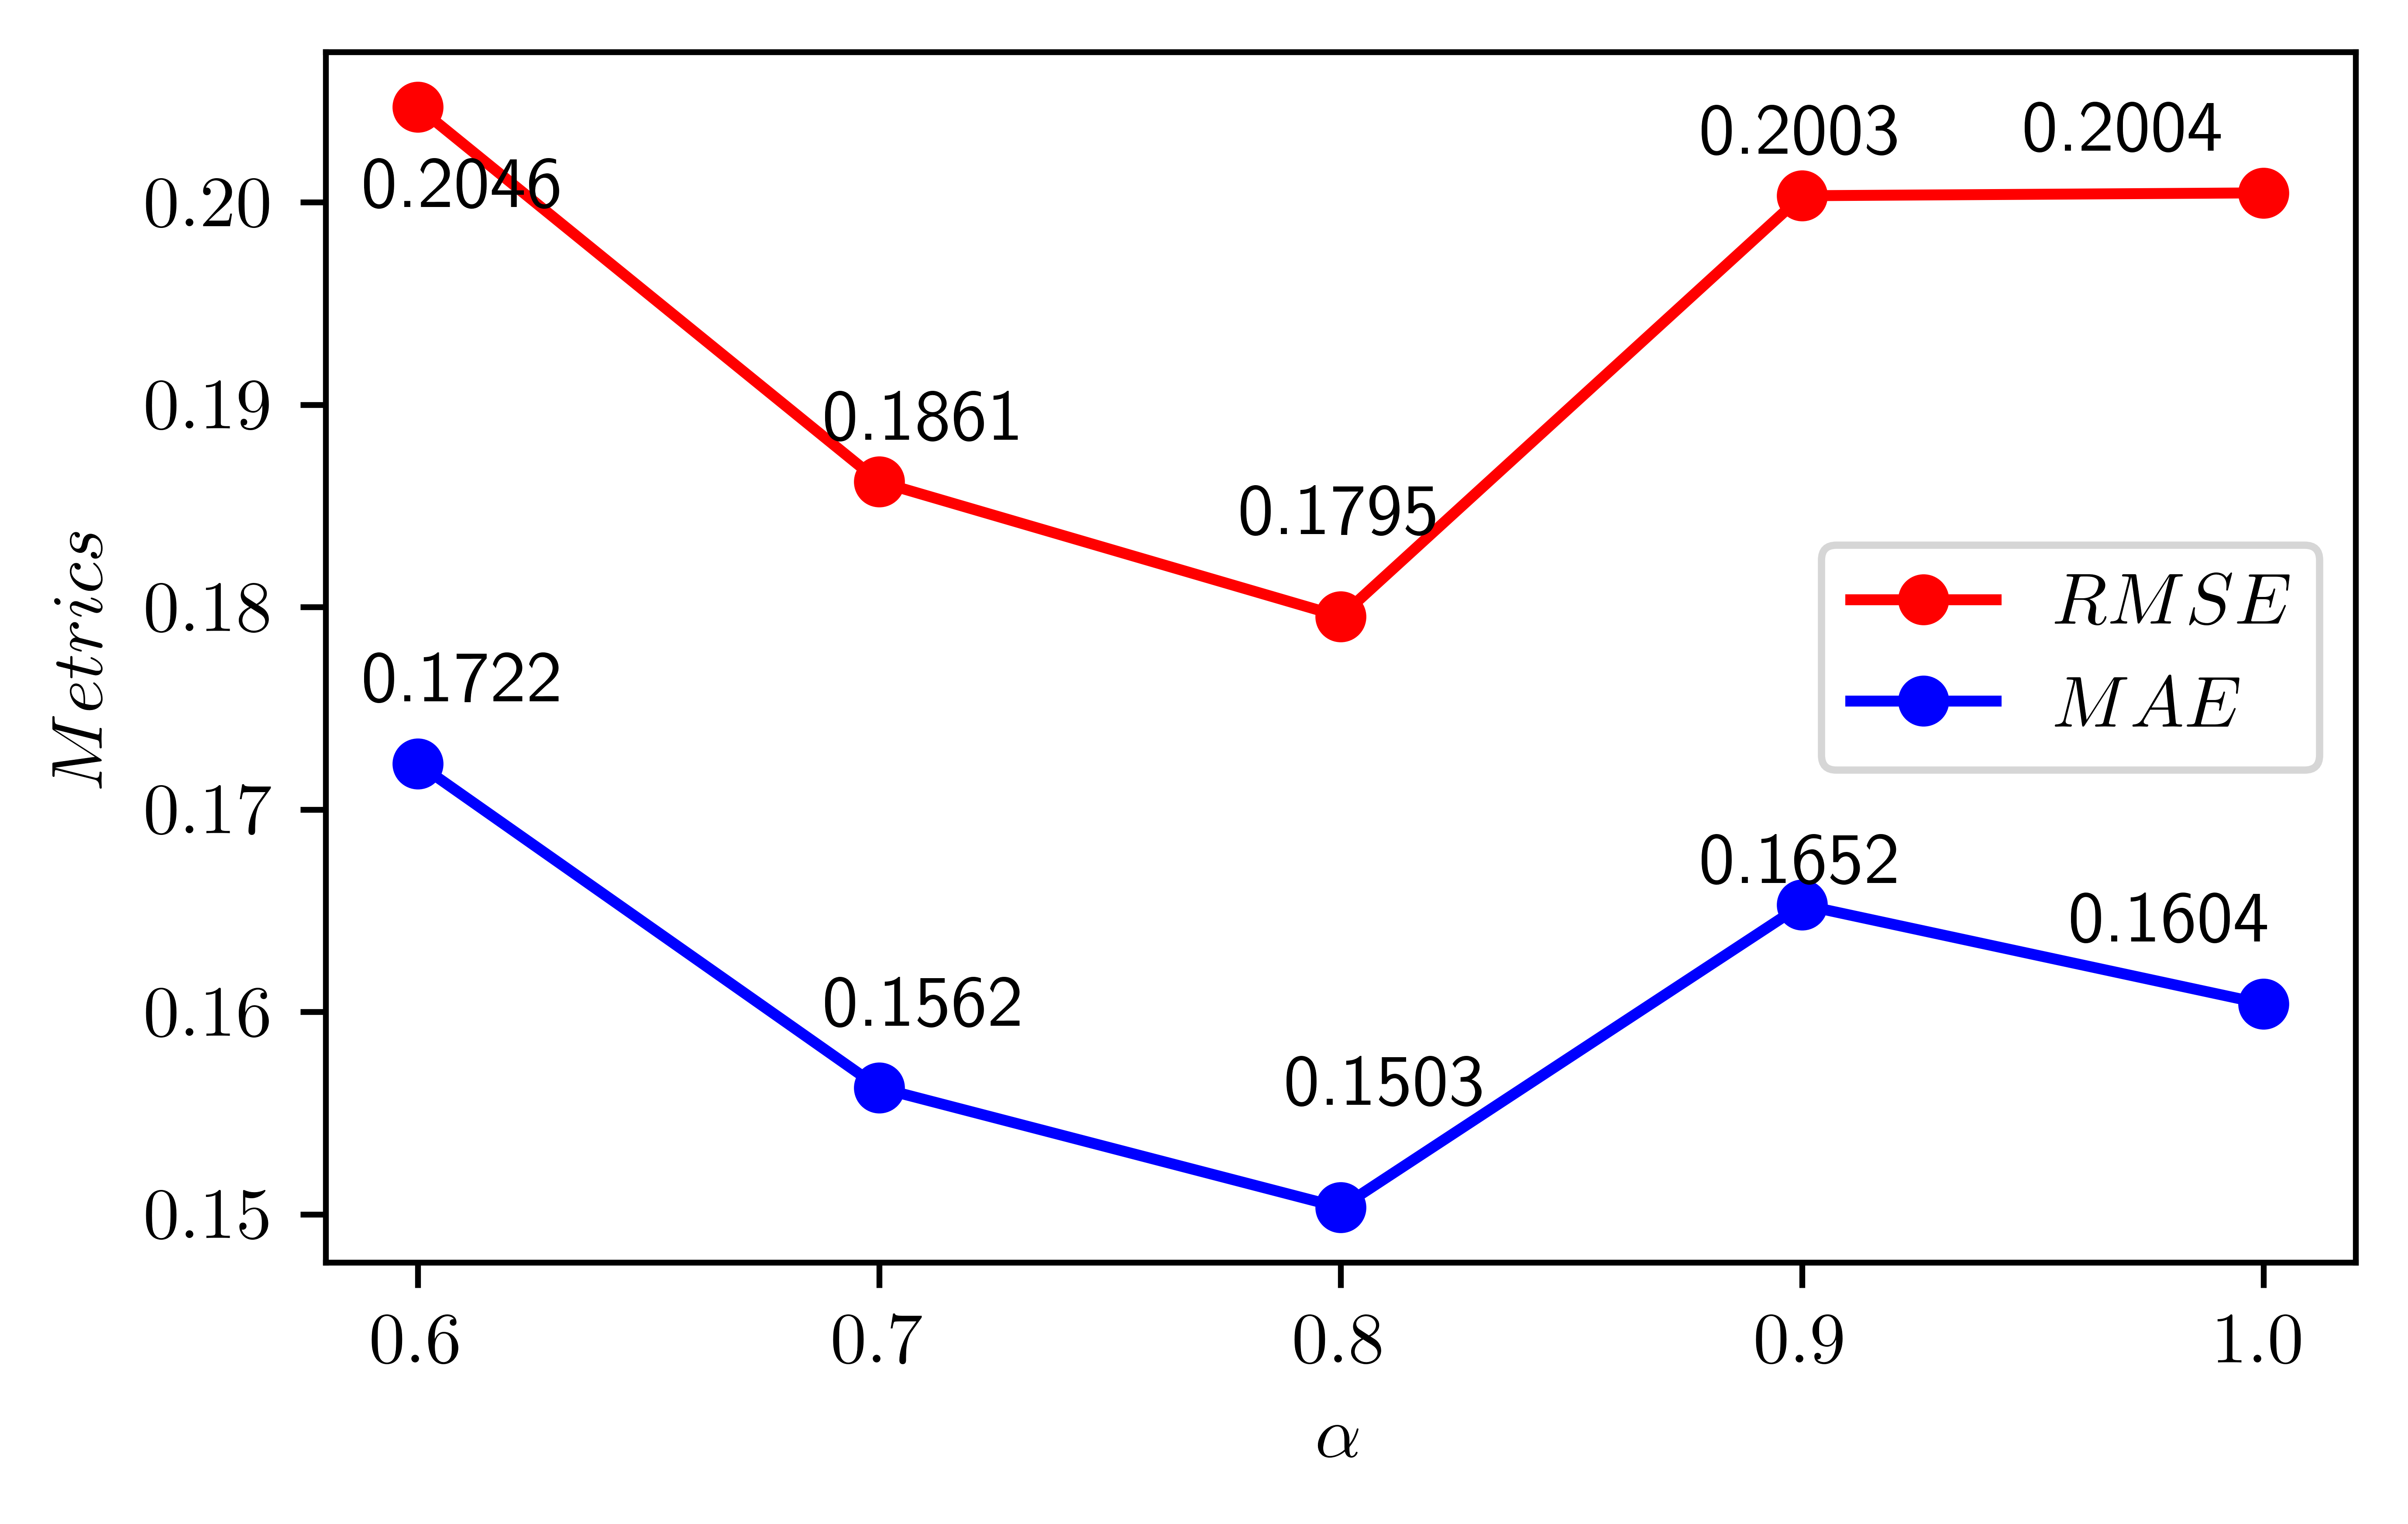

In [338]:
plt.figure(figsize=(5,3),dpi=1200)   #1200

plt.plot(x,RMSE_ETTh1,'o-',c='r',label=r'$RMSE$')
plt.plot(x,MAE_ETTh1,'o-',c='b',label=r'$MAE$')
# plt.plot(x,MAPE_ETTh1,'o-',c='darkgreen',label=r'$MAPE$')

#RMSE
plt.text(0.61, 0.1996998, f'0.2046', ha='center')
plt.text(0.71, 0.18819123, f'0.1861', ha='center')
plt.text(0.8, 0.18353438, f'0.1795', ha='center')
plt.text(0.9, 0.20232546, f'0.2003', ha='center')
plt.text(0.97, 0.20246733, f'0.2004', ha='center')

#MAE
plt.text(0.61, 0.17526346, f'0.1722', ha='center')
plt.text(0.71, 0.15925323, f'0.1562', ha='center')
plt.text(0.81, 0.15533492, f'0.1503', ha='center')
plt.text(0.9, 0.16629681, f'0.1652', ha='center')
plt.text(0.98, 0.16340143, f'0.1604', ha='center')

# #MAPE
# plt.text(0.61, 0.39894334, f'0.3889', ha='center')
# plt.text(0.71, 0.32905958, f'0.3190', ha='center')
# plt.text(0.81, 0.3308023, f'0.3208', ha='center')
# plt.text(0.9, 0.3101764, f'0.3001', ha='center')
# plt.text(0.97, 0.5008389, f'0.5108', ha='center')

plt.xticks(x)
plt.ylabel('$Metrics$')
plt.xlabel(r'$\alpha$')
plt.legend()
plt.ticklabel_format(axis='both', style='scientific', scilimits=(-2, 2), useMathText=True)
# plt.savefig('picture/Fig5_c.svg',bbox_inches='tight',format='svg')
# plt.savefig('picture/Fig5_c.pdf',bbox_inches='tight',format='pdf')
plt.show()